# Text Exploratory Analysis & Cleaning

This notebook explores raw customer feedback text to understand its structure,
length, and common patterns. The goal is to identify appropriate preprocessing
steps before applying sentiment analysis and topic modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

## Load Customer Feedback Data

We use a representative sample of customer reviews to keep analysis efficient
while preserving real-world text variability.

In [3]:
df = pd.read_csv("../data/raw/reviews_sample.csv")
df.head()

,Text,Score
0,Having tried a couple of other brands of glute...,5
1,My cat loves these treats. If ever I can't fin...,5
2,A little less than I expected. It tends to ha...,3
3,"First there was Frosted Mini-Wheats, in origin...",2
4,and I want to congratulate the graphic artist ...,5


## Dataset Overview

We begin by inspecting dataset size and rating distribution to understand
overall sentiment tendencies.

In [4]:
df.shape

(10000, 2)

In [5]:
df["Score"].value_counts().sort_index()

Score
1     891
2     507
3     750
4    1455
5    6397
Name: count, dtype: int64

## Review Length Analysis

Text length provides insight into verbosity and helps identify extremely
short or unusually long reviews.

In [6]:
df["text_length"] = df["Text"].astype(str).apply(len)

df["text_length"].describe()

count    10000.000000
mean       433.967600
std        431.991743
min         35.000000
25%        182.000000
50%        299.000000
75%        522.000000
max       8642.000000
Name: text_length, dtype: float64

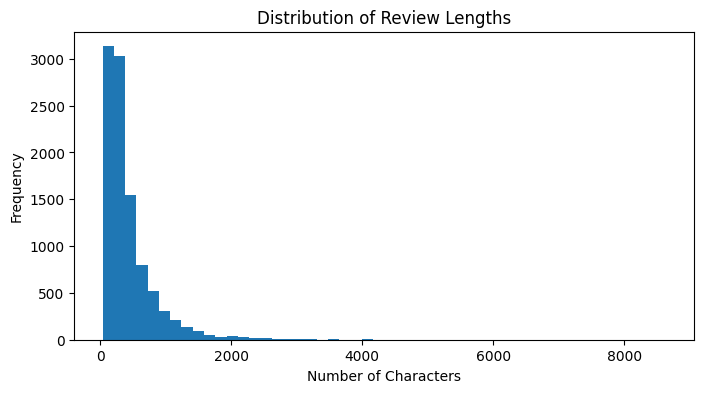

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

## Text Cleaning Strategy

Before modeling, raw text is cleaned to:
- Normalize case
- Remove punctuation and numbers
- Reduce noise from irrelevant symbols

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [9]:
df["clean_text"] = df["Text"].astype(str).apply(clean_text)
df[["Text", "clean_text"]].head()

,Text,clean_text
0,Having tried a couple of other brands of glute...,having tried a couple of other brands of glute...
1,My cat loves these treats. If ever I can't fin...,my cat loves these treats if ever i cant find ...
2,A little less than I expected. It tends to ha...,a little less than i expected it tends to have...
3,"First there was Frosted Mini-Wheats, in origin...",first there was frosted miniwheats in original...
4,and I want to congratulate the graphic artist ...,and i want to congratulate the graphic artist ...


## Observations After Cleaning

- Text normalization significantly reduces noise.
- Cleaned text is more suitable for vectorization and modeling.
- Some semantic nuance is lost, but overall signal improves.

## Next Steps

- Use cleaned text for sentiment analysis
- Transform text into numerical features
- Apply supervised and unsupervised NLP techniques